# Tutorial . Electrocardiograma con la clase EM  . 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM


## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Clase EM ](#EM)

[2.1 Ejemplo de objeto EKG con sus métodos ](#CO)

[2.1.1 Picos R y QRS](#PR)

[2.1.2 Onda P](#EM2)

[2.1.3 Onda T](#Der)


## Introducción

El objetivo de este tutorial es emplear la clase de Electromiograma (EM) para el análisis específico de un Electrocardiograma (EKG). Para ello, utilizaremos el atributo tipo, el cual nos permitirá integrar métodos exclusivos para el estudio del EKG. A lo largo del tutorial, se presentarán ejemplos básicos de su uso.

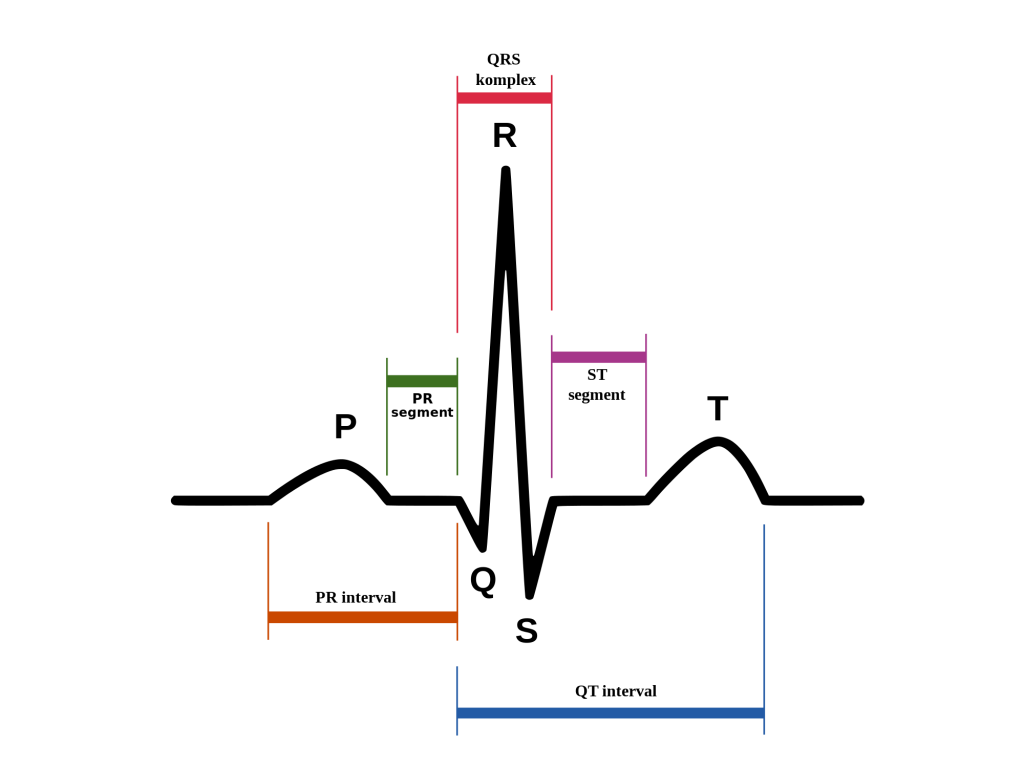

## Inicialización del Notebook

Primero prepararemos el entorno adecuado para el notebook

In [1]:
# Librerias
import numpy as np
import random as rd
import wave
import sys
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from scipy.signal import butter, lfilter, filtfilt #fFiltrado de datos
from statistics import stdev
import scipy.stats as scs 
sys.path.insert(1, r'./../functions') 

# Gráficas
%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 16 
plt.rcParams['axes.titlesize'] = 18 
plt.rcParams['font.size'] = 14
plt.rcParams['lines.linewidth'] = 1.4 

## Clase EM


In [2]:
from Clase_ECG import EM

### Ejemplo de objeto EKG con sus métodos 

In [3]:
#Creamos un objeto EKG con un archivo .wav

#Registro Largo en el cual se sometio a diversos ambientes 
ECG=EM(archivo='/Users/danielyedra/Desktop/Electro_fisio/electrophys/ECG/ECGbasics/data/ECGexercise/S4_ECG_resting.wav',tipo="EKG")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {ECG.señal}")
print(f"Tiempo de la señal: {ECG.vector_tiempo[-1]} segundos")
print(f'Tipo de registro: {ECG.get_tipo()}')
ECG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 10000 Hz.
Señal de la muestra: [-270 -270 -270 ...  300  270  240]
Tiempo de la señal: 203.3308 segundos
Tipo de registro: EKG
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 2033308
  - Mínimo y máximo: (-12120, 11430)
  - Media: -34.7173
  - Varianza: 7441274.6108
  - Asimetría: 1.1964
  - Curtosis: 9.5512


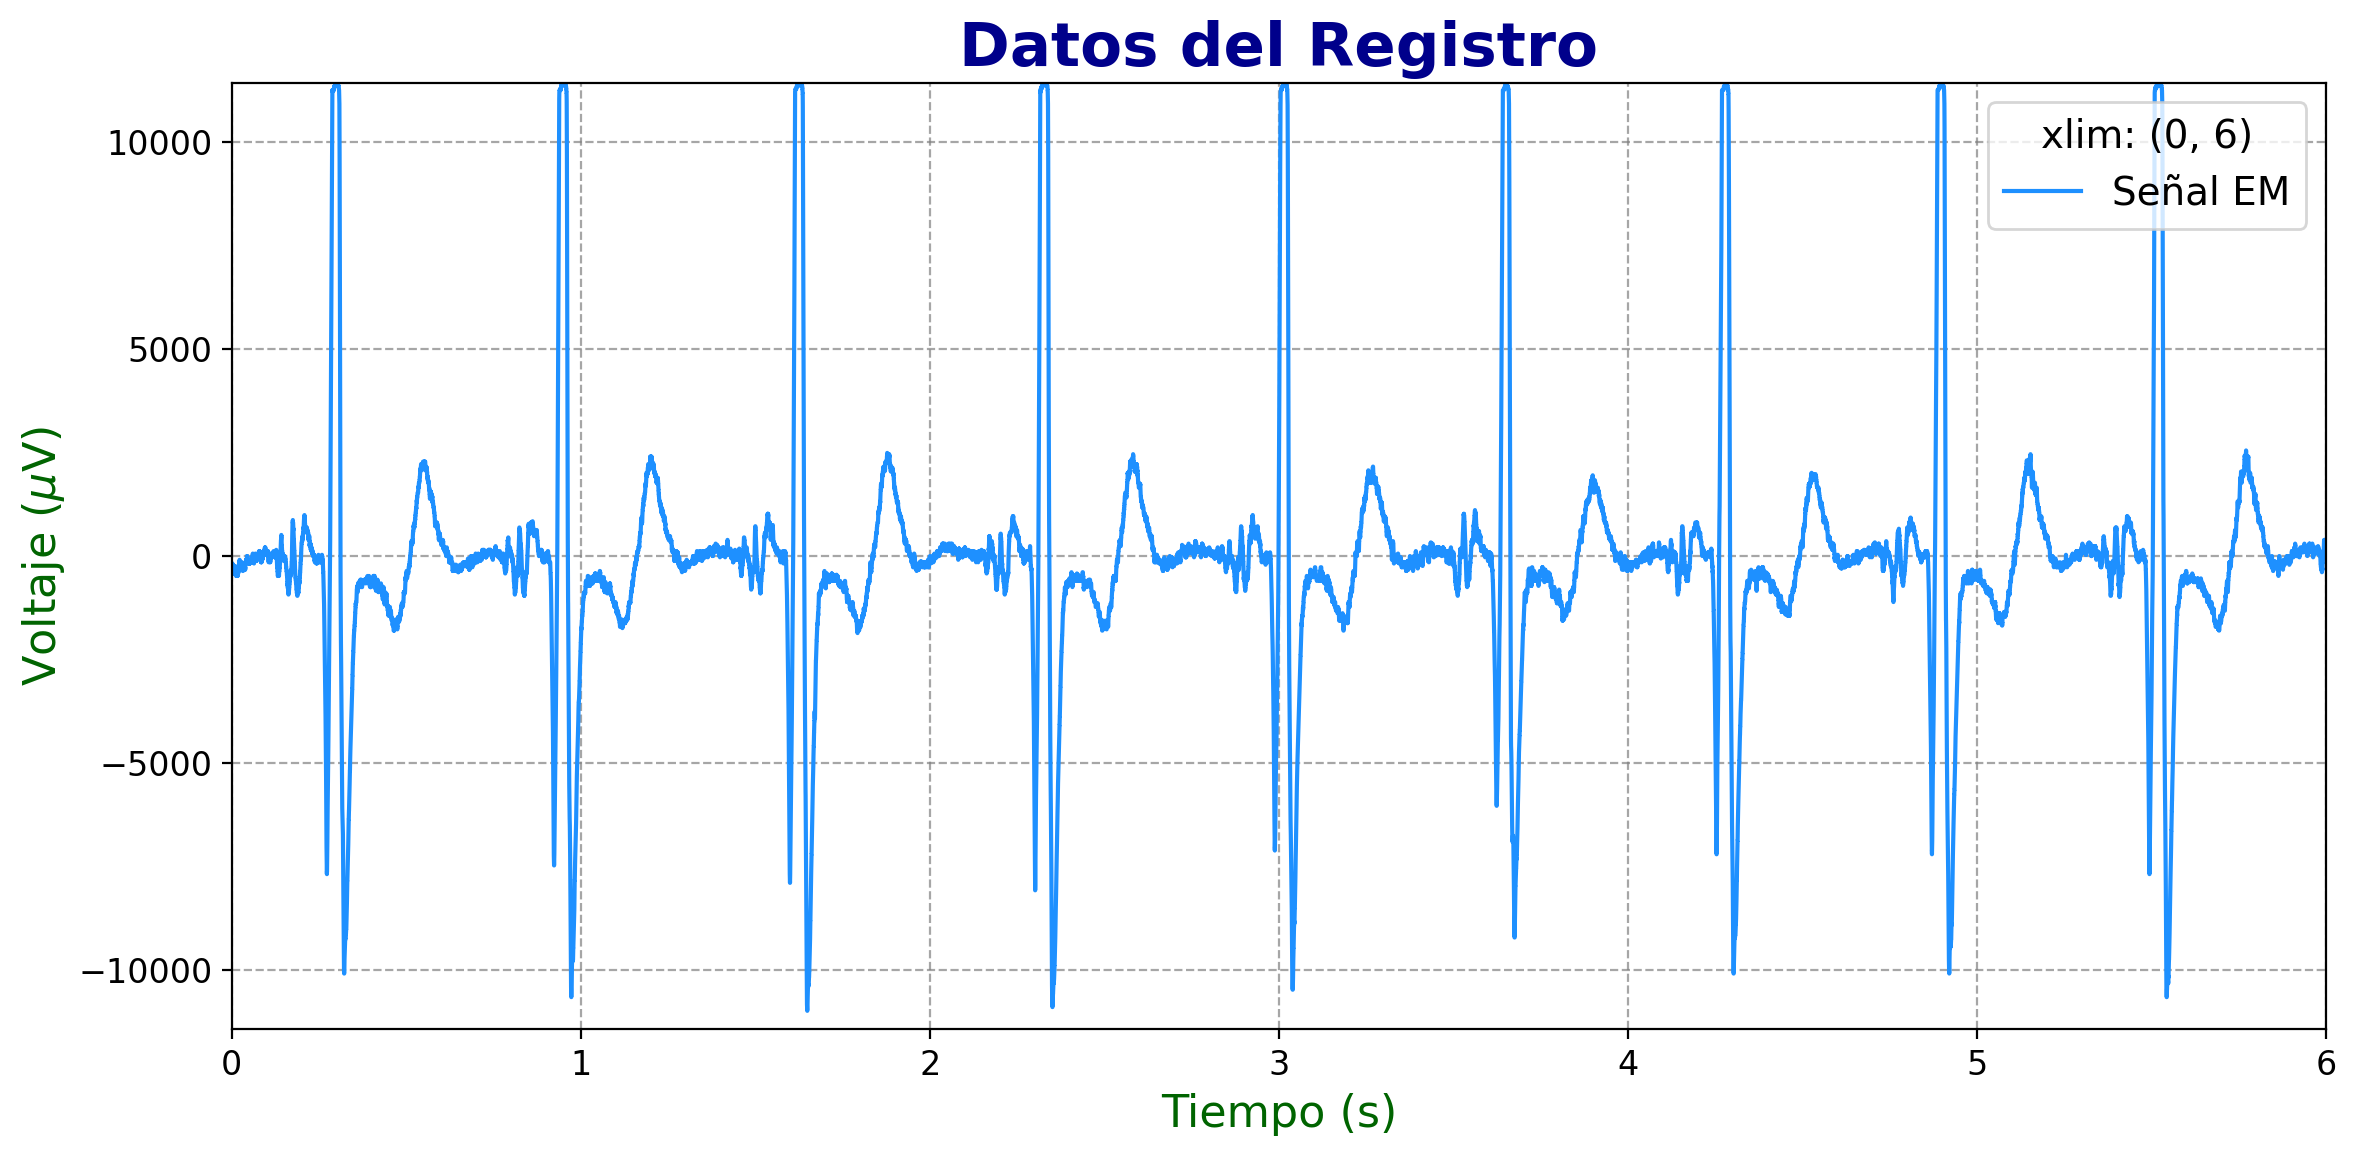

In [4]:
ECG.visualizar(0,6)

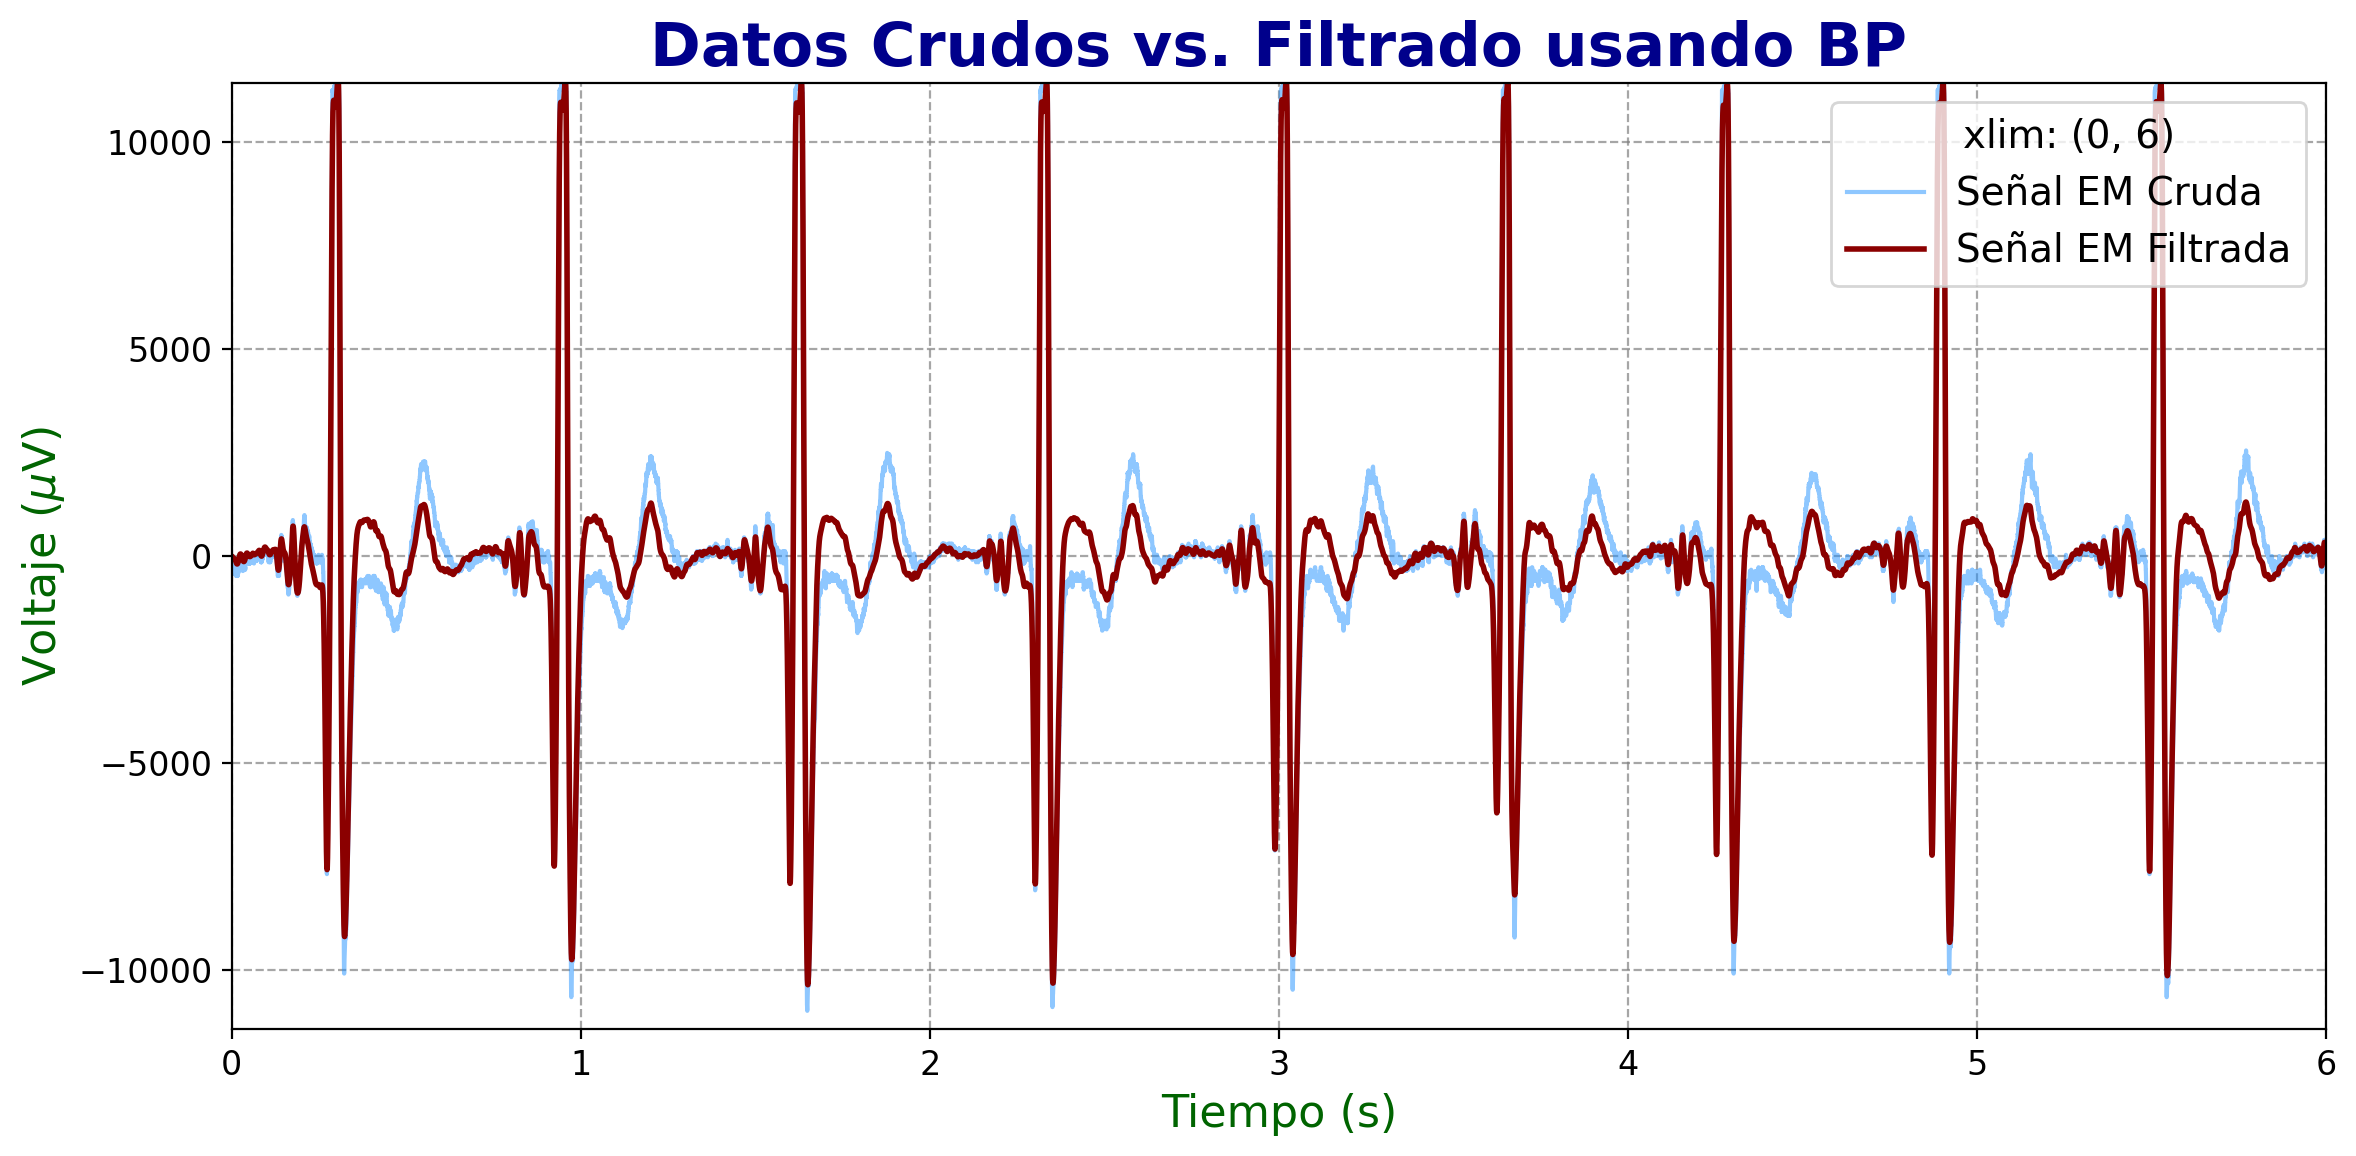

In [5]:
ECG.visualizar_filtrada(0,6,5,90)

In [6]:
ECG_F=EM(señal=ECG.Señal_filtrada_Bandpass(5,90), tasa_muestra=ECG.tasa_muestra ,tipo="EKG") #Creamos un nuevo objeto ECG filtrado

 Cortamos el segmento del registro con el que vamos a trabajar

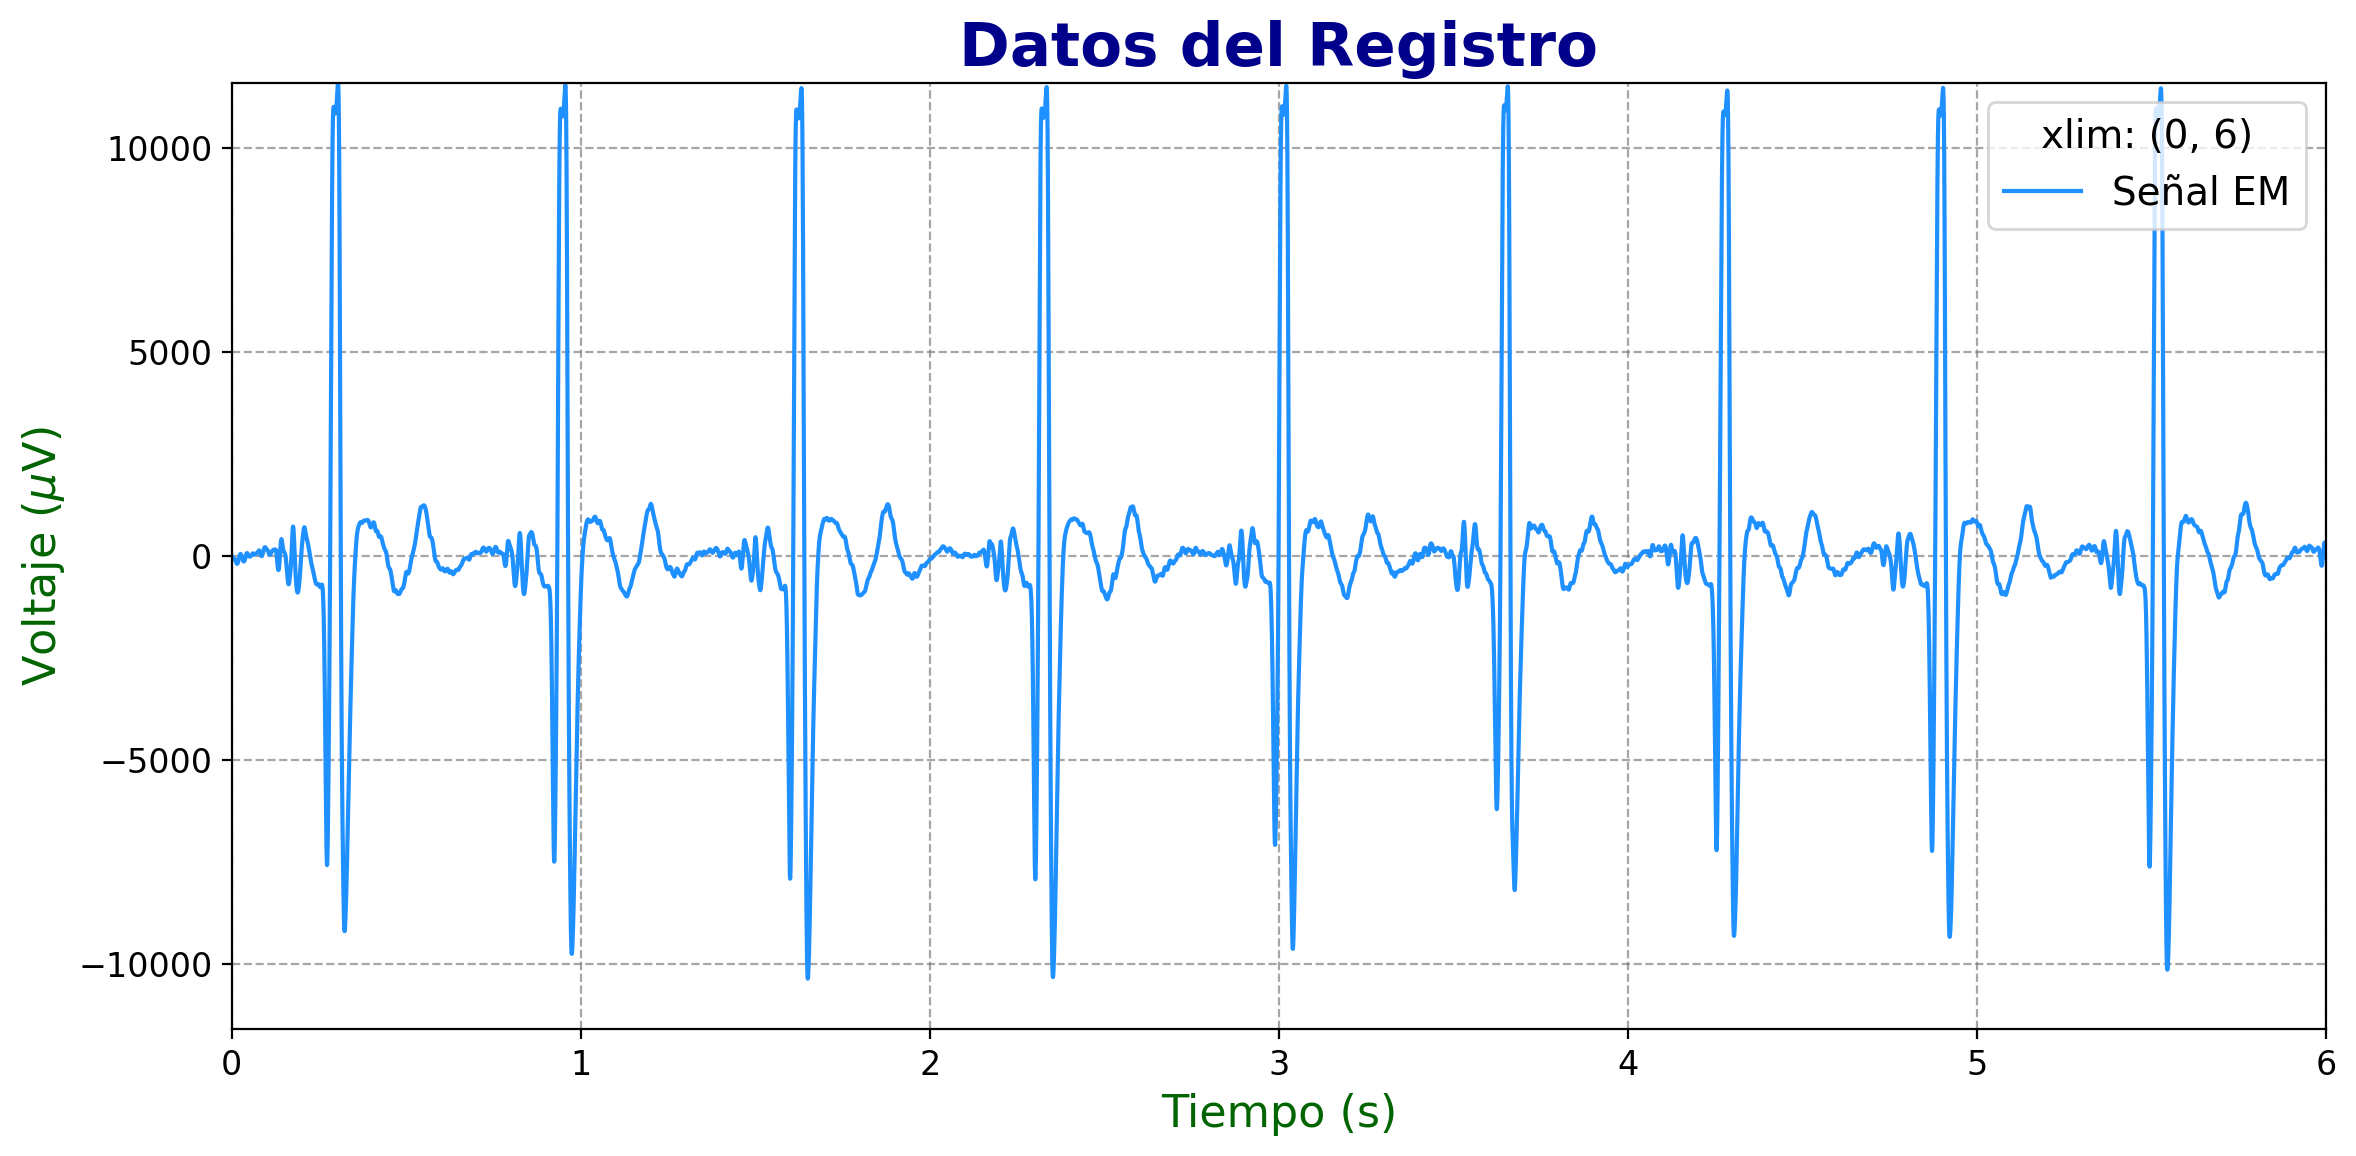

In [7]:
# Cortamos el segmento que vamos a analizar
ECG_FR = ECG_F.cortar_segmento(0,6)
ECG_FR.visualizar(0, 6)  # Graficamos el segmento del nuevo EKG

In [8]:
#Definimos el segmento del registro como EKG
ECG_FR.set_tipo('EKG') 

## Métodos Basicos para EKG

Para los siguientes métodos que vamos a ocupar es preferible ocupar un segmento del registro. 

Los métodos que vamos a menciona ya se mostraron en el Tutorial "Human electrocardiogram basic analysis", asi que vamos a mostrar como llamar a los metodos:

* Detección de Picos R y intervalos R-R:  EKG.PicosR(T) tiene como parametro T el umbral y regresa los indices donde ocurren los Picos R

Recuerda usar un segmento del registro


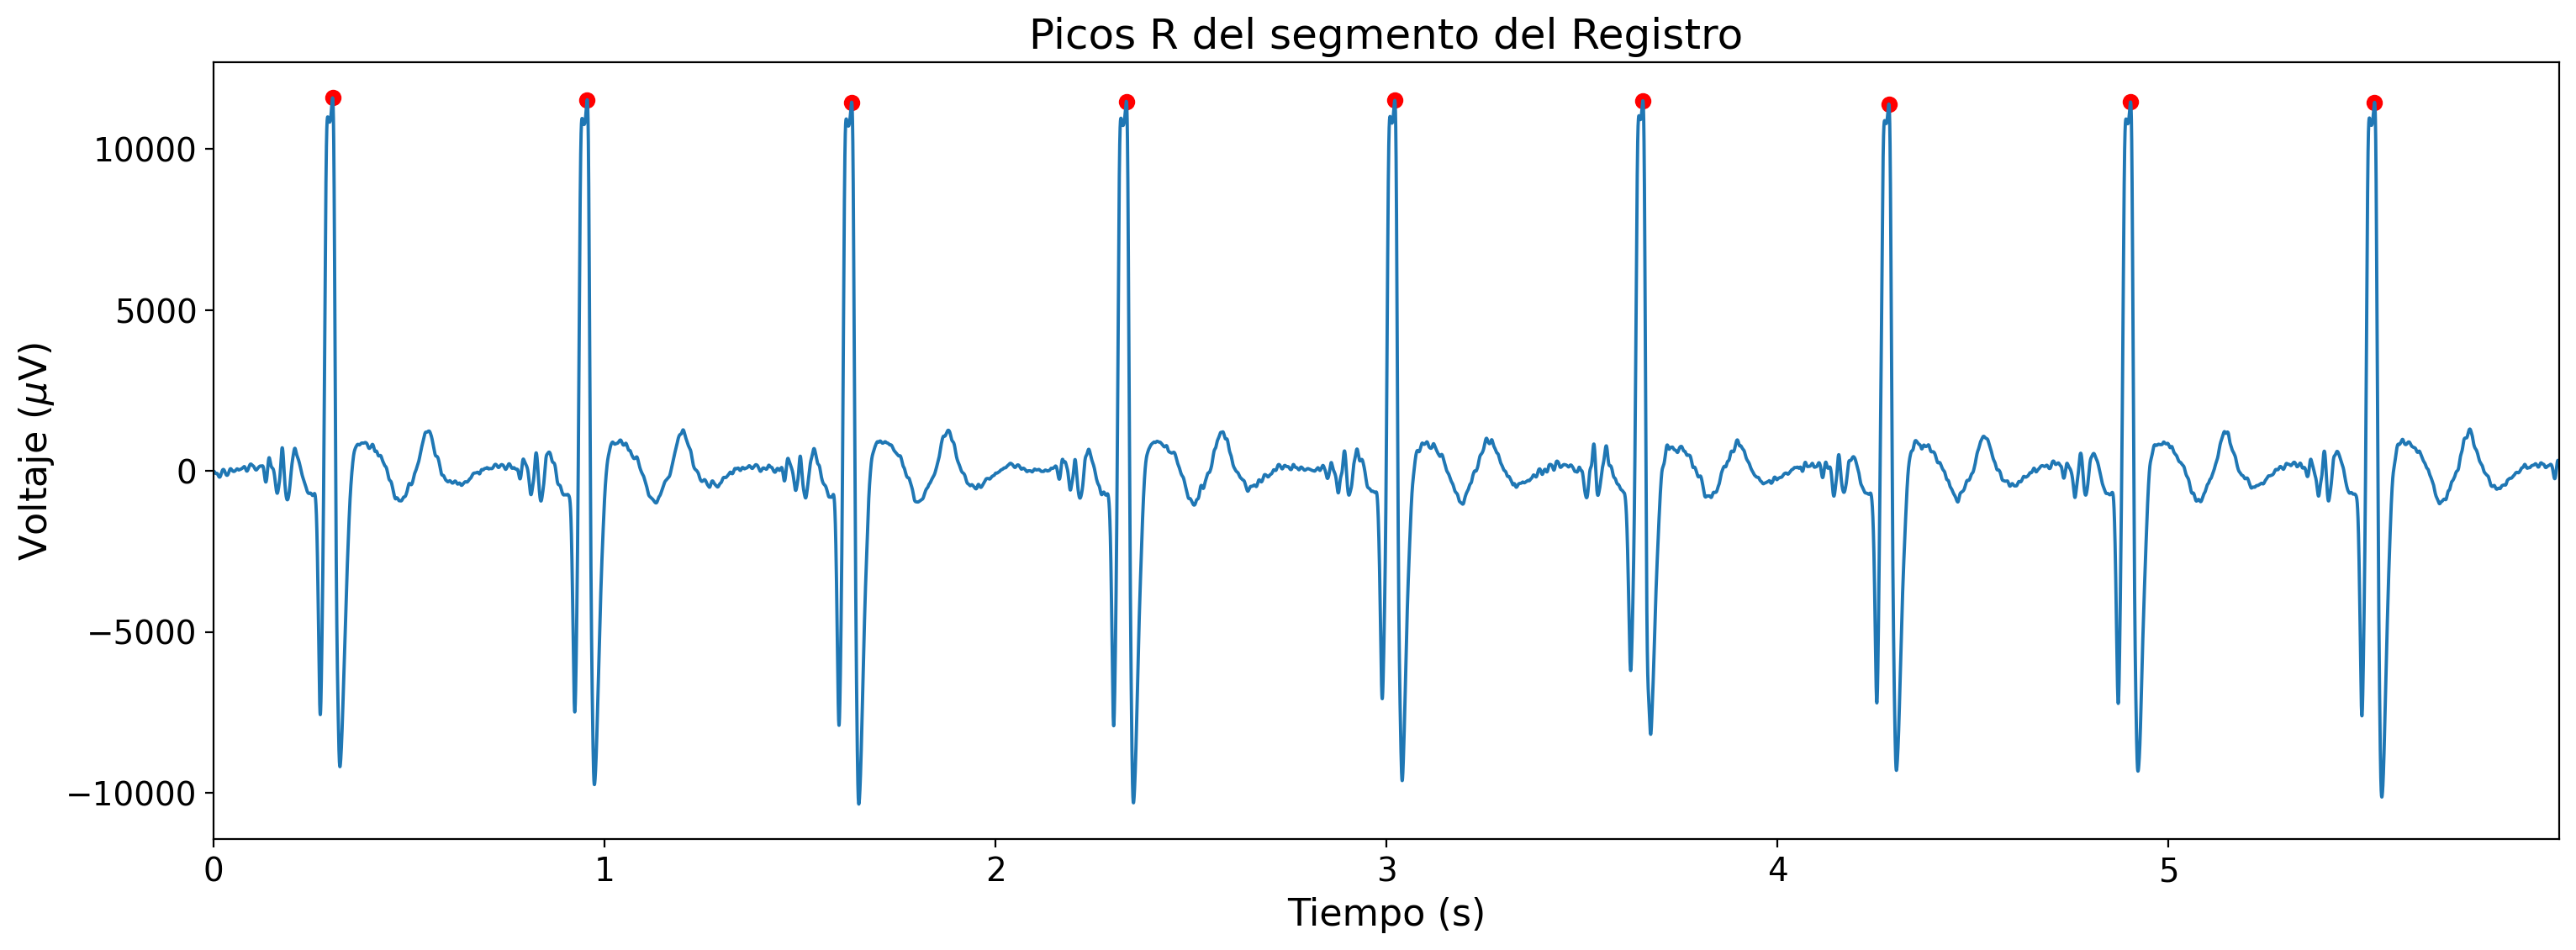

In [9]:
A=ECG_FR.PicosR(0.87) 

* Latidos por Minuto y Frecuencia Cardiaca: EKG.LPM_FC(mxs_indices) tiene como parametro los indices donde ocurren los Picos R y regresa una lista con el promedio de latidos por minuto, frecuencia cardiaca.

Latidos por minuto: 90.00145576141614


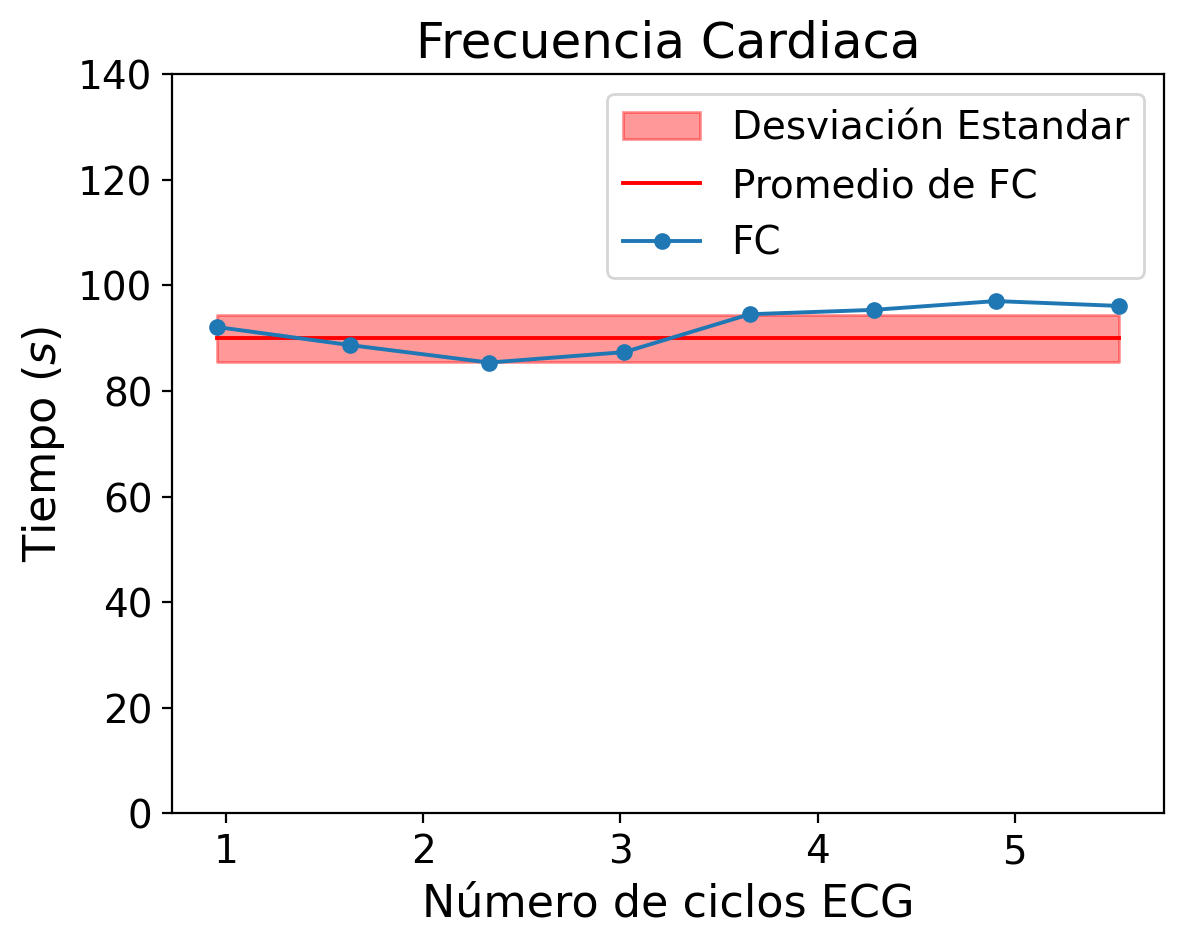

In [10]:
B=ECG_FR.LPM_FC(mxs_indices=A)

* Intervalos R-R: Tenemos los métodos EKG.Intervalos_RR(mxs_indices) que tiene como parametros los indices donde ocurren los picos R  y regresa una lista con los intervalos R-R y su promedio

Promedio del intervalo R-R :  0.6529128211086668


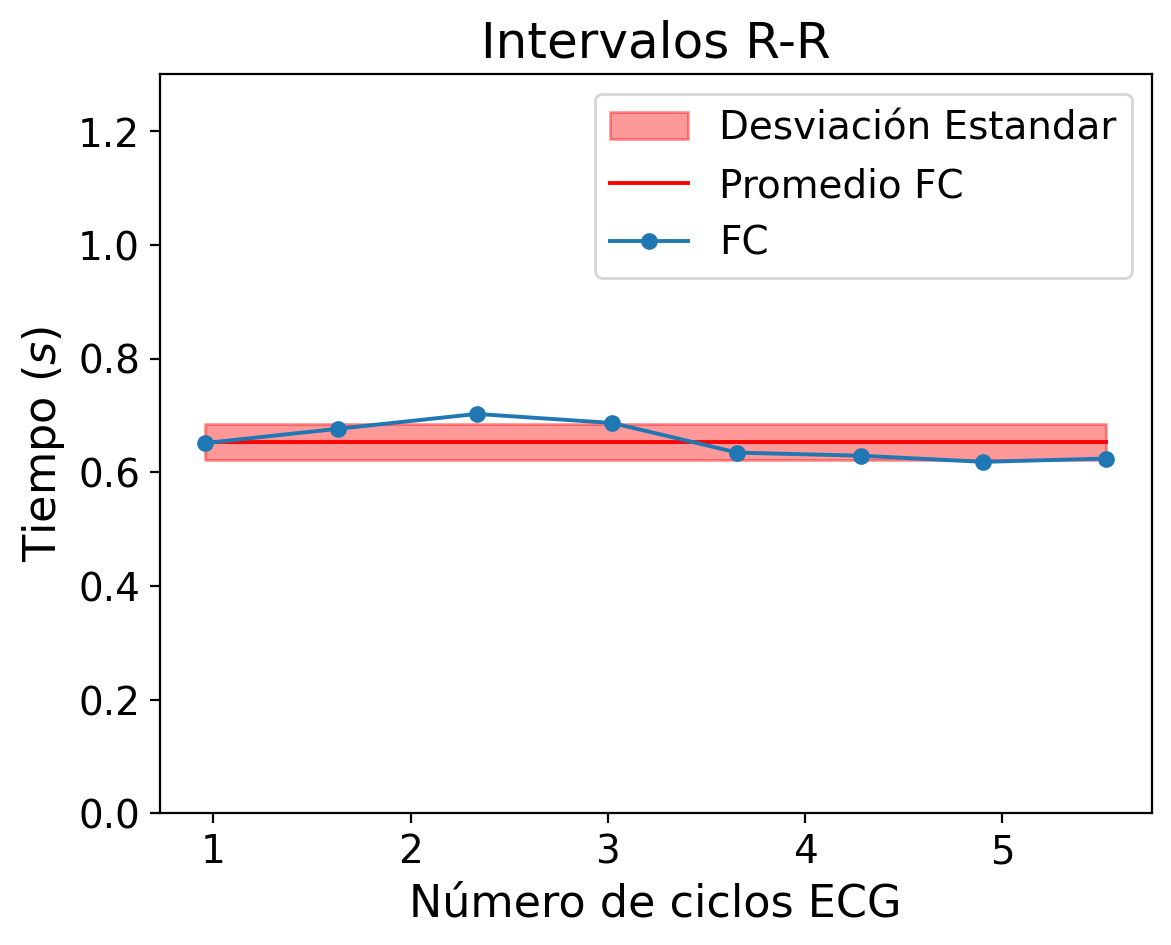

In [11]:
C=ECG_FR.Intervalos_RR(mxs_indices=A) 

* El siguiente método muestra la relación entre Frecuencia Cardiaca e Intervalos R-R

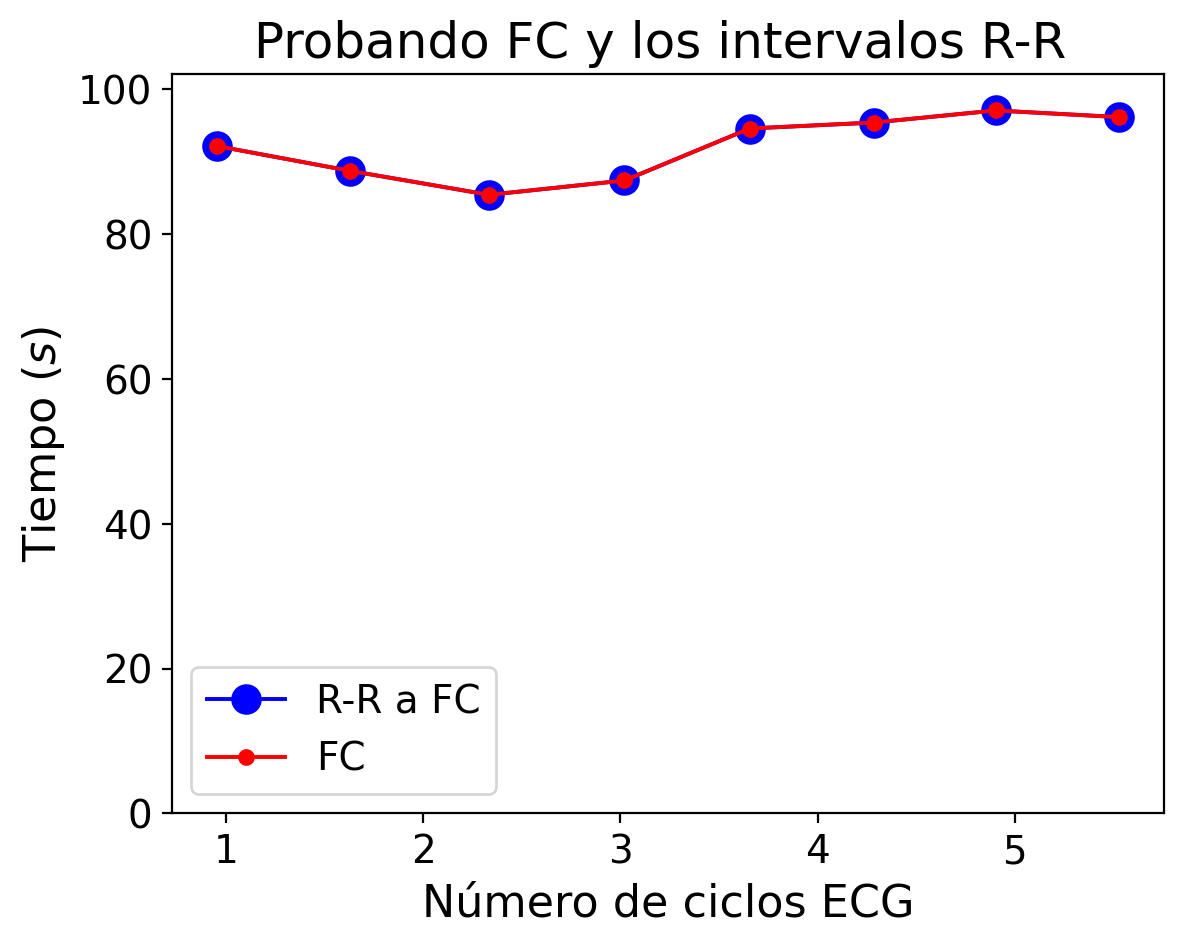

In [12]:
ECG_FR.Prueba_FCRR(xx=C[0],heart_rate=B[-1],mxs_indices=A) 

* Componentes del ECG: EKG.QRS1(mxs_indices) tiene como parametro los indices donde ocurren los picos R y regresa los  indices los puntos mínimos antes y despues del pico R.


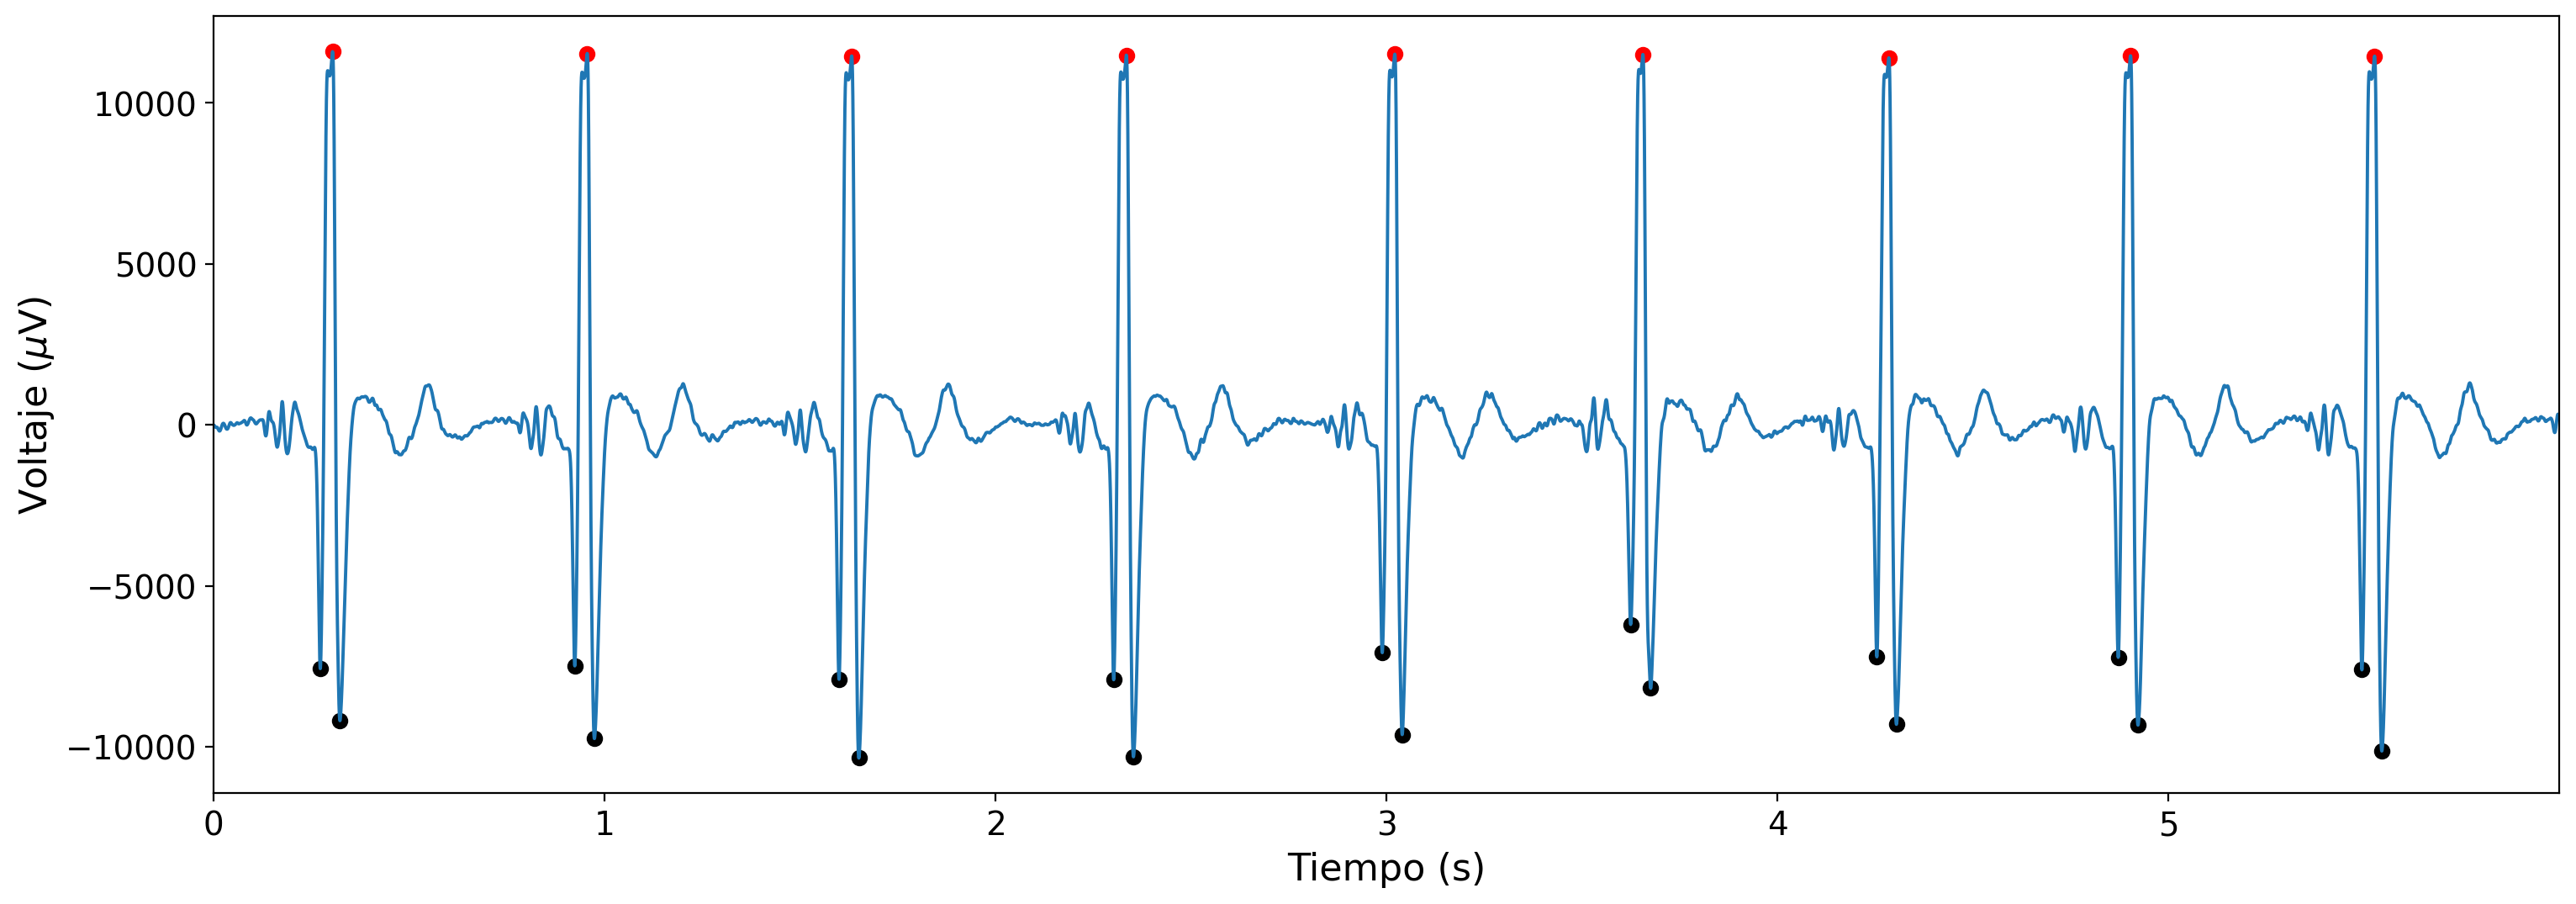

In [13]:
 D=ECG_FR.QRS(mxs_indices=A) #Regresa los puntos azules

El promedio en segundos del complejo QRS es:  0.05060002488556817


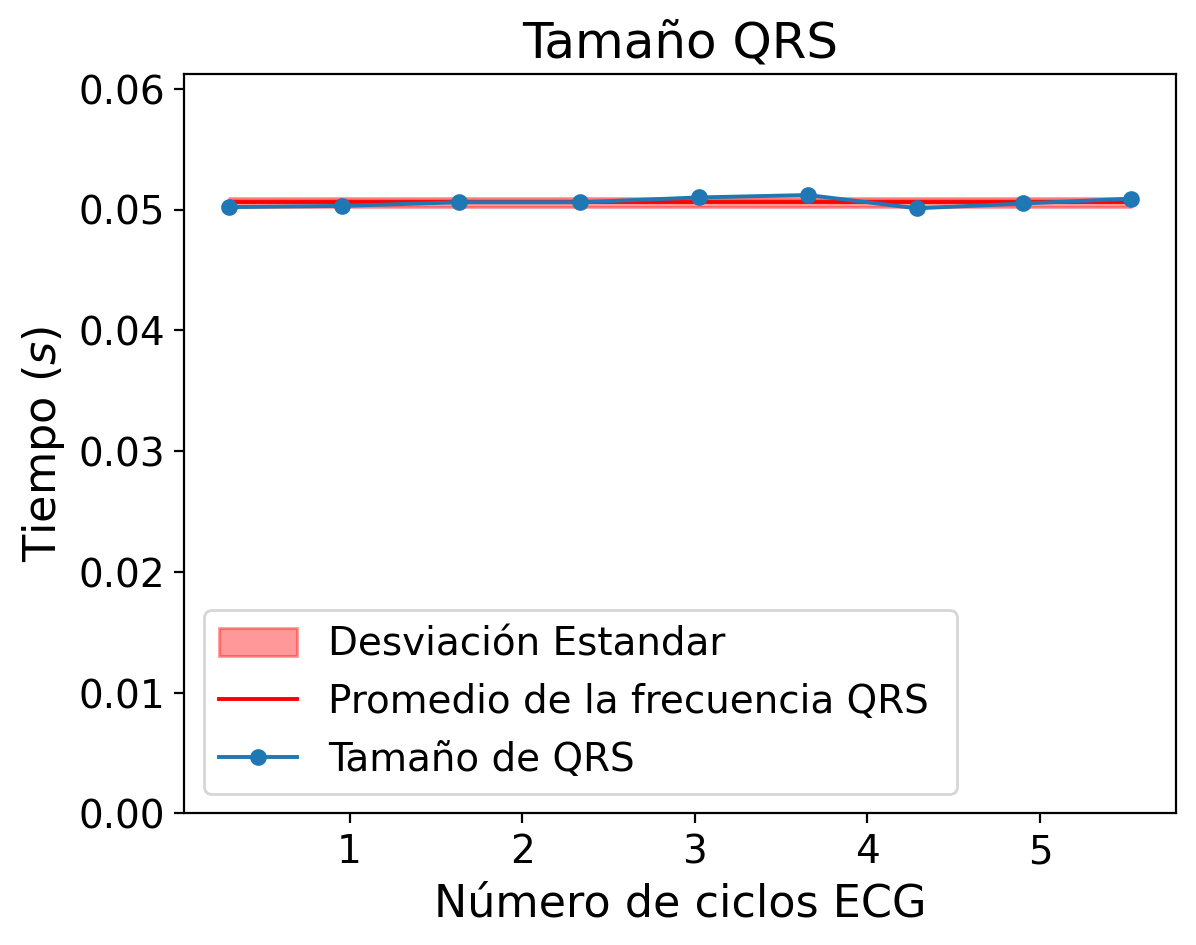

In [14]:
E=ECG_FR.Tamaño_QRS(mxs_indices=A,mins_try=D)

* La onda P debido a su baja amplitud y corta duración es más complicado estimarla, por esto se creo el siguiente método que  estima el inicio y fin de esta: ECG.P_wave(mxs_indices,mins_try,nn,VD) donde aquí son importante los parametros nn y VD que son el número de muestras antes del mínimo (Q) donde se buscará el inicio de la onda P y ventana de muestras para calcular la derivada (cuán brusco cambia el voltaje) respectivamente.

In [15]:
E=ECG_FR.P_wave(mxs_indices=A,mins_try=D,nn=800,VD=200) 

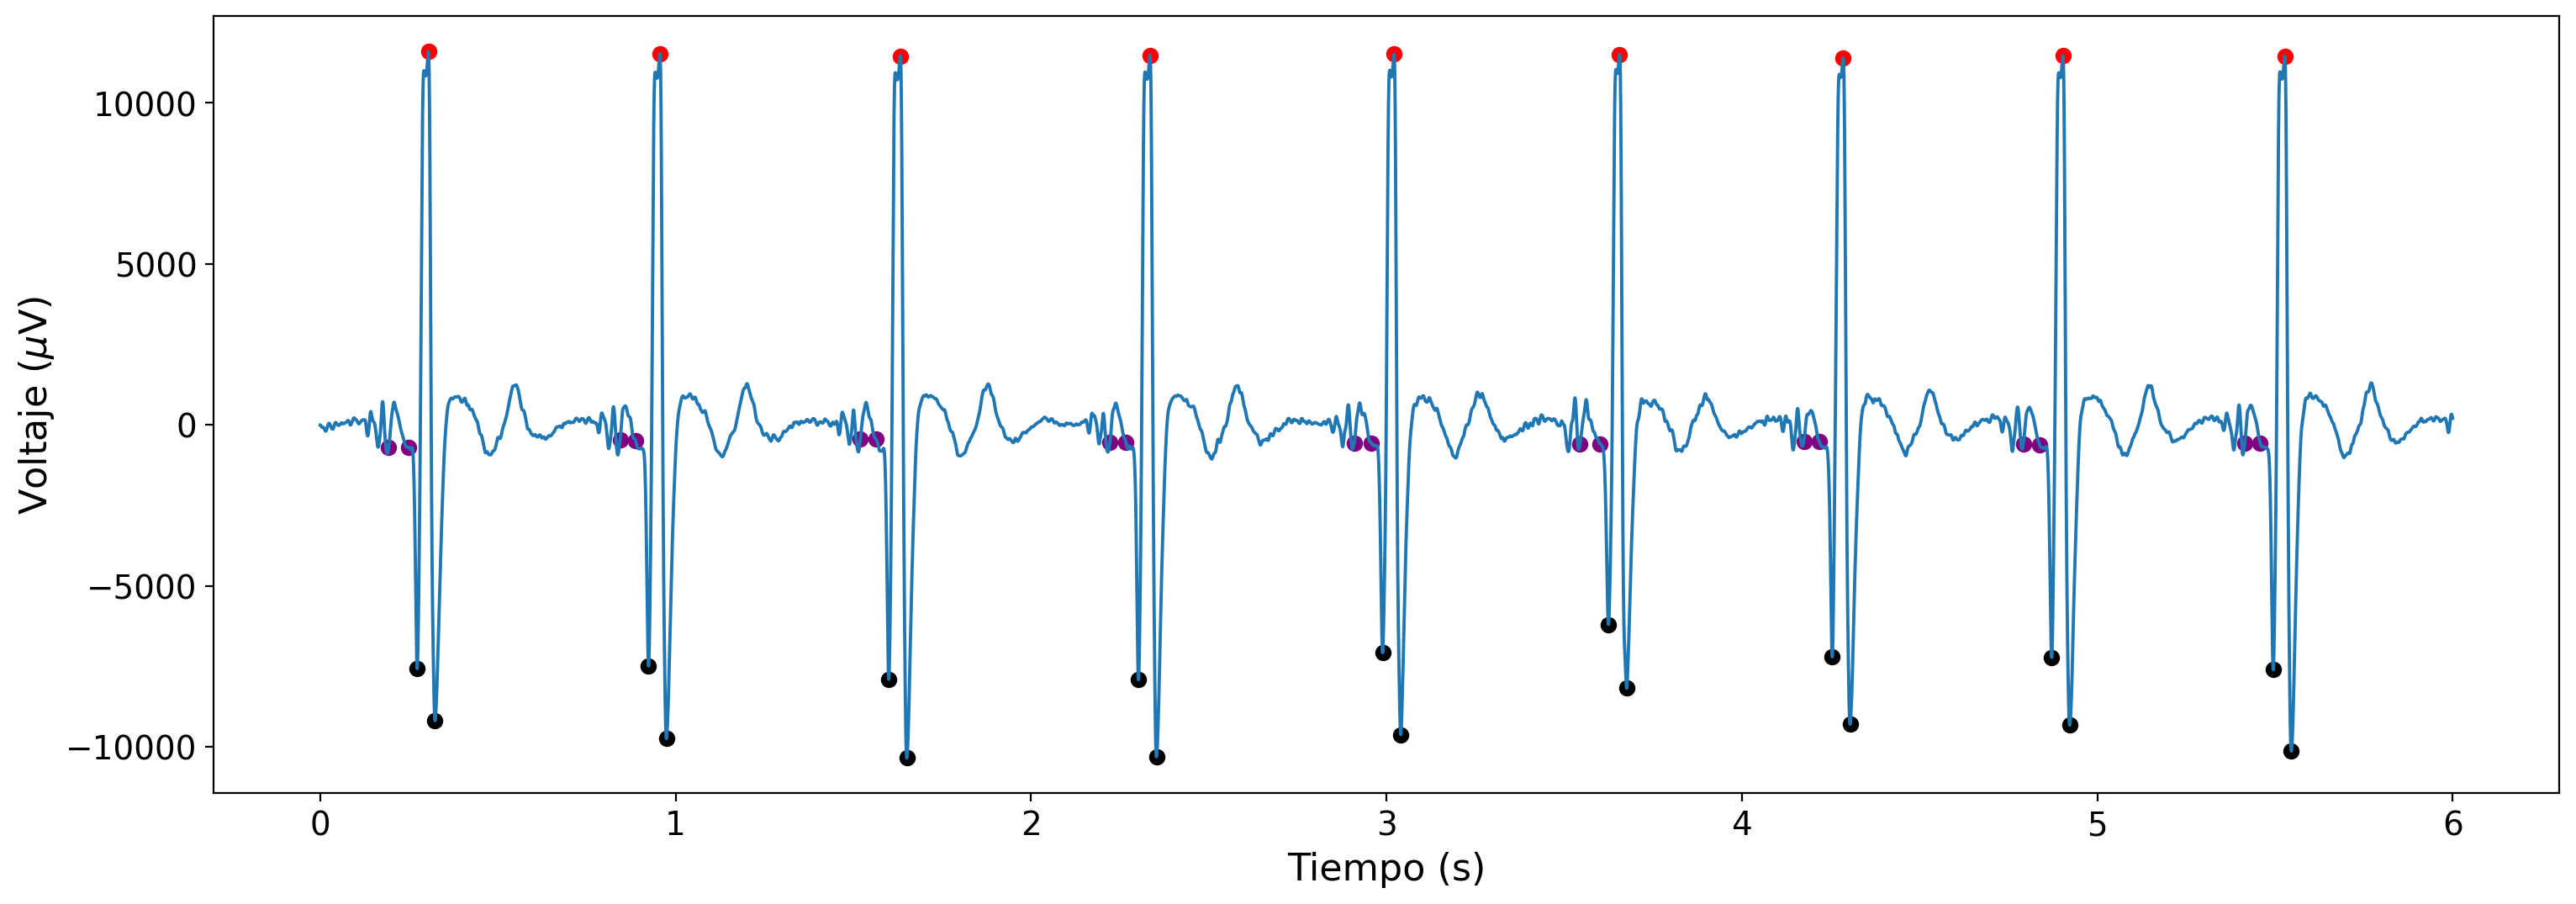

In [16]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo,ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')
plt.show()

Para hacer un Zoom a la gráfica se puede ocupar el siguiente código

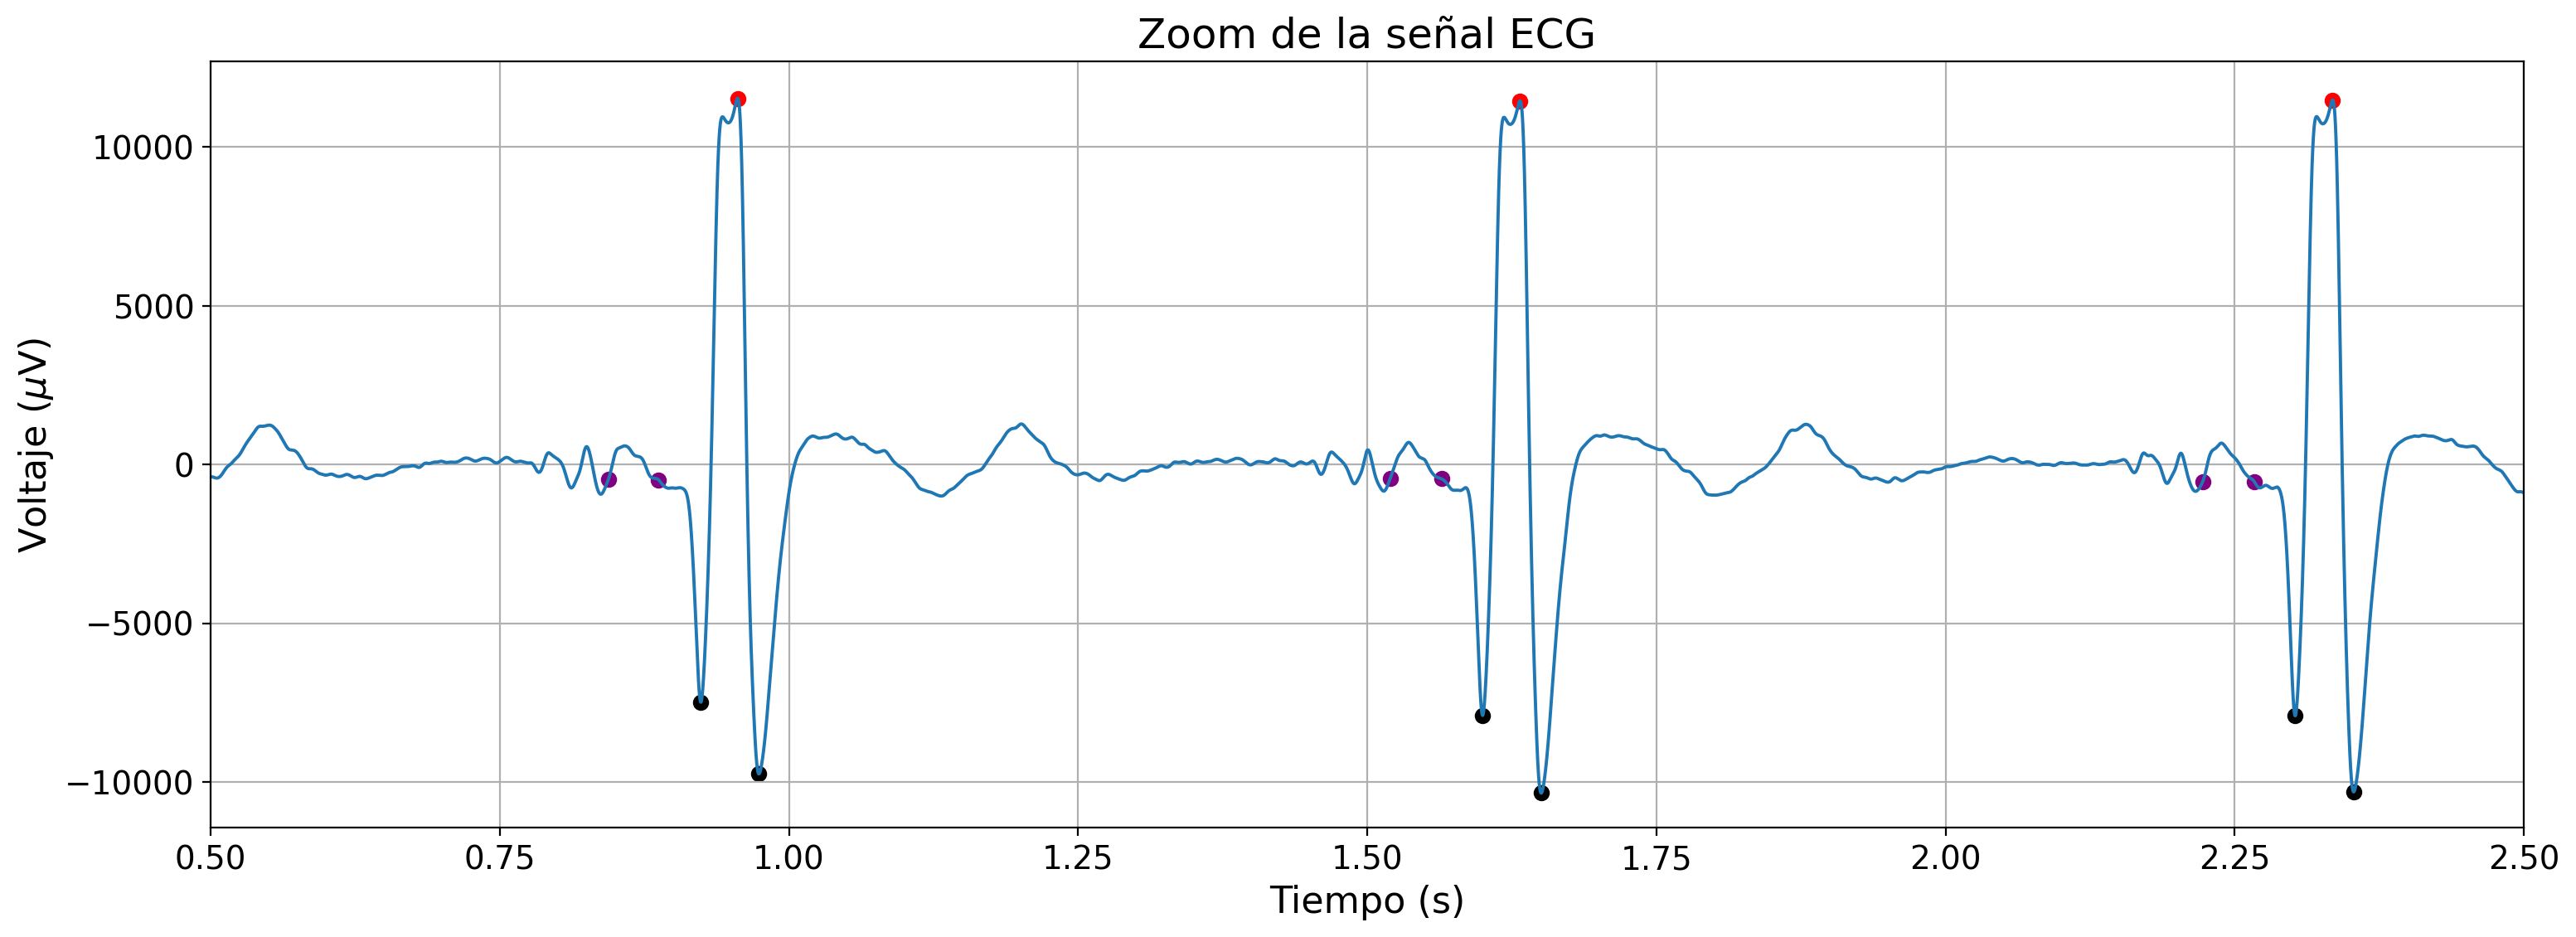

In [17]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo, ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')

# Zoom:
plt.xlim(0.5, 2.5)  # Zoom en eje X (tiempo)

plt.title("Zoom de la señal ECG")
plt.grid(True)
plt.show()

Promedio en segundos de la P-wave:  0.04615002269701535


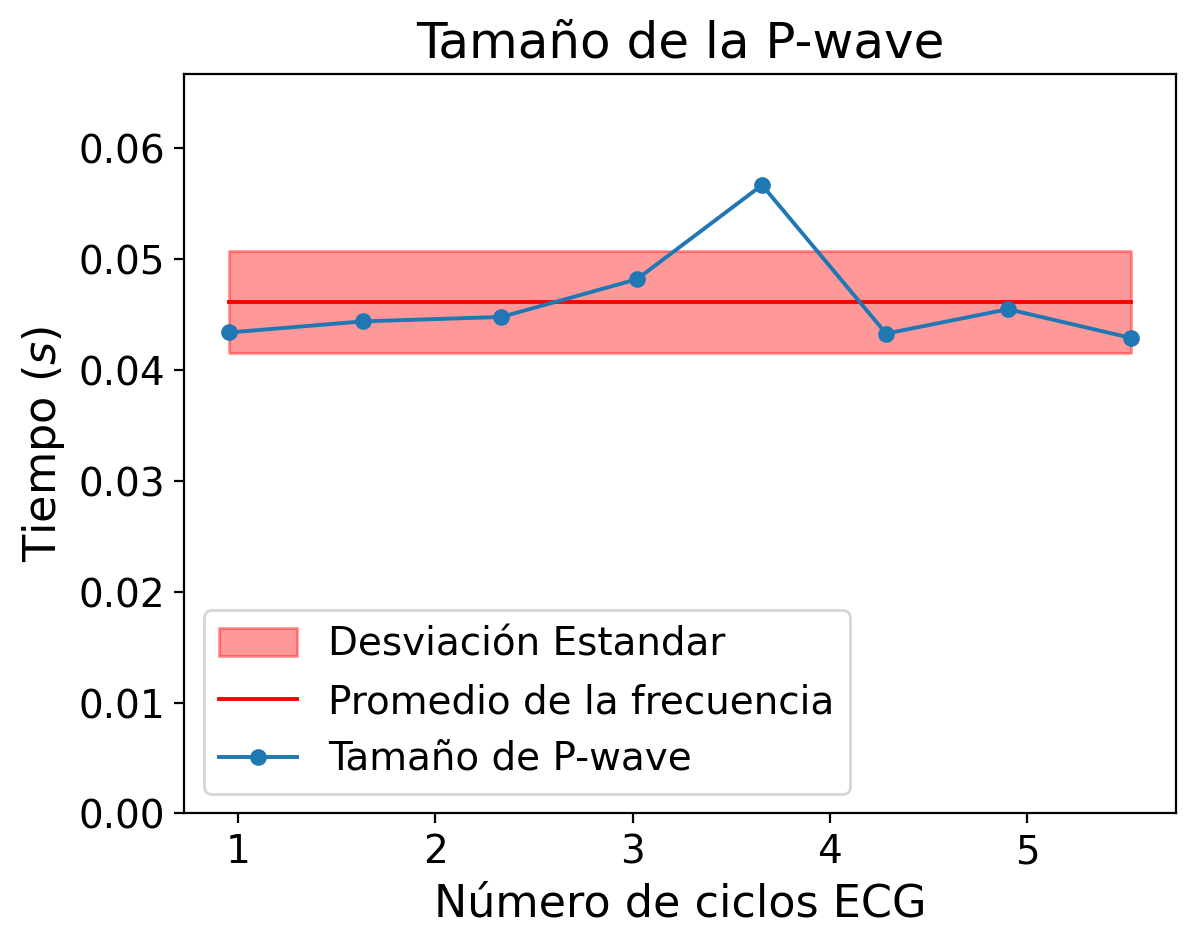

In [18]:
ECG_FR.Tamaño_Pwave(E[0],E[1],A)

* Para la detección de la onda T se implementará un método similar al utilizado para la onda P, en el sentido de que se requerirán parámetros como el número de muestras posteriores al pico R para iniciar la búsqueda del comienzo y final de la onda. Asimismo, se emplearán ventanas de muestras para el cálculo de la derivada: una ventana inicial más amplia, destinada a identificar un inicio suave de la onda T, y una ventana final más estrecha, enfocada en detectar un punto de inflexión agudo al final de la misma.

In [19]:
F=ECG_FR.T_wave(mxs_indices=A,mins_try=D,nni=1500,nnf=3000,VDI=200,VDF=100)

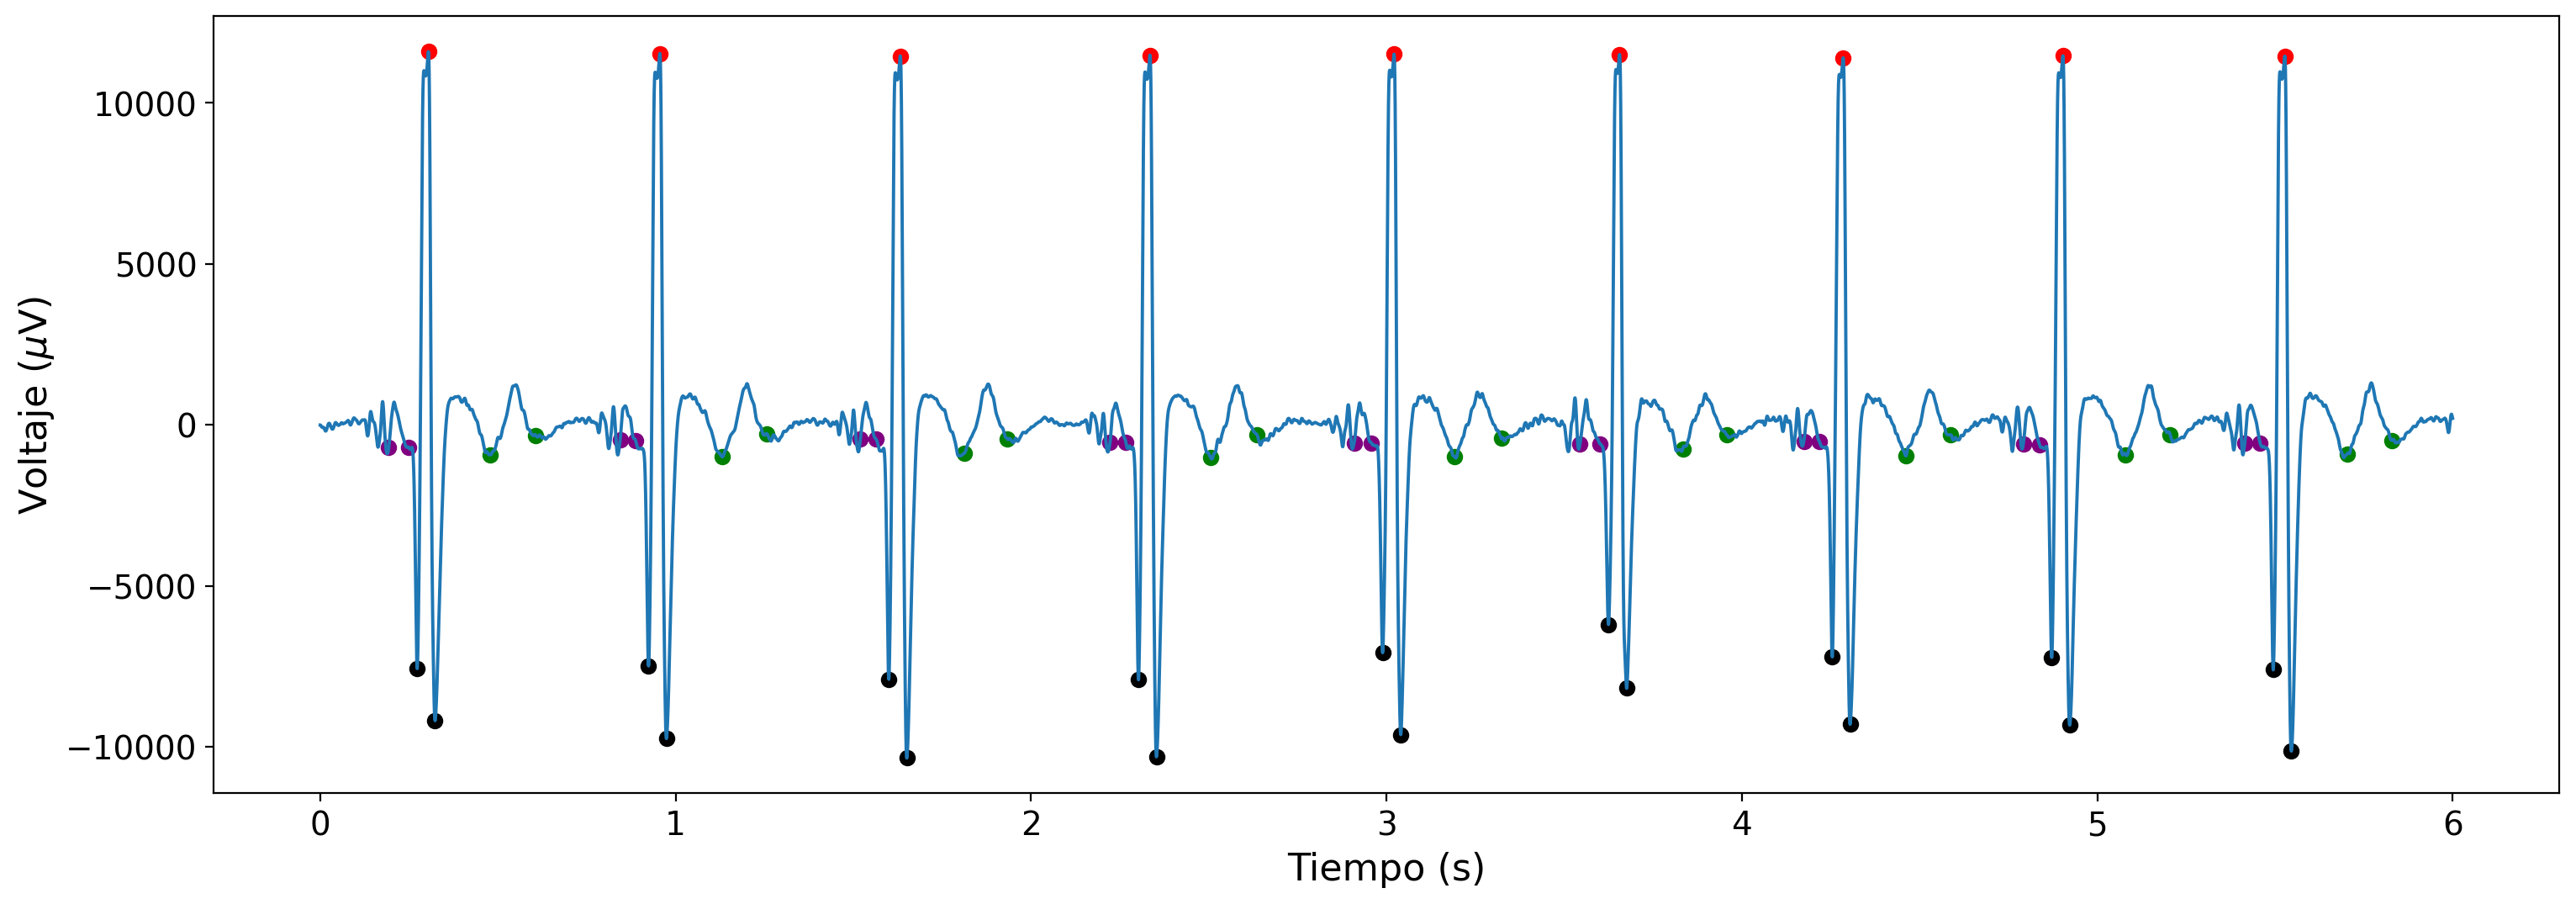

In [20]:
plt.figure(figsize=(18,6))
plt.xlabel(r'Tiempo (s)')
plt.ylabel(r'Voltaje ($\mu$V)')
plt.plot(ECG_FR.vector_tiempo,ECG_FR.señal)
plt.scatter(ECG_FR.vector_tiempo[A], ECG_FR.señal[A], color='r')
plt.scatter(ECG_FR.vector_tiempo[D], ECG_FR.señal[D], color='k')
plt.scatter(ECG_FR.vector_tiempo[E], ECG_FR.señal[E], color='purple')
plt.scatter(ECG_FR.vector_tiempo[F], ECG_FR.señal[F], color='green')
plt.show()

Promedio en segundos de la T-wave:  0.126750062336873


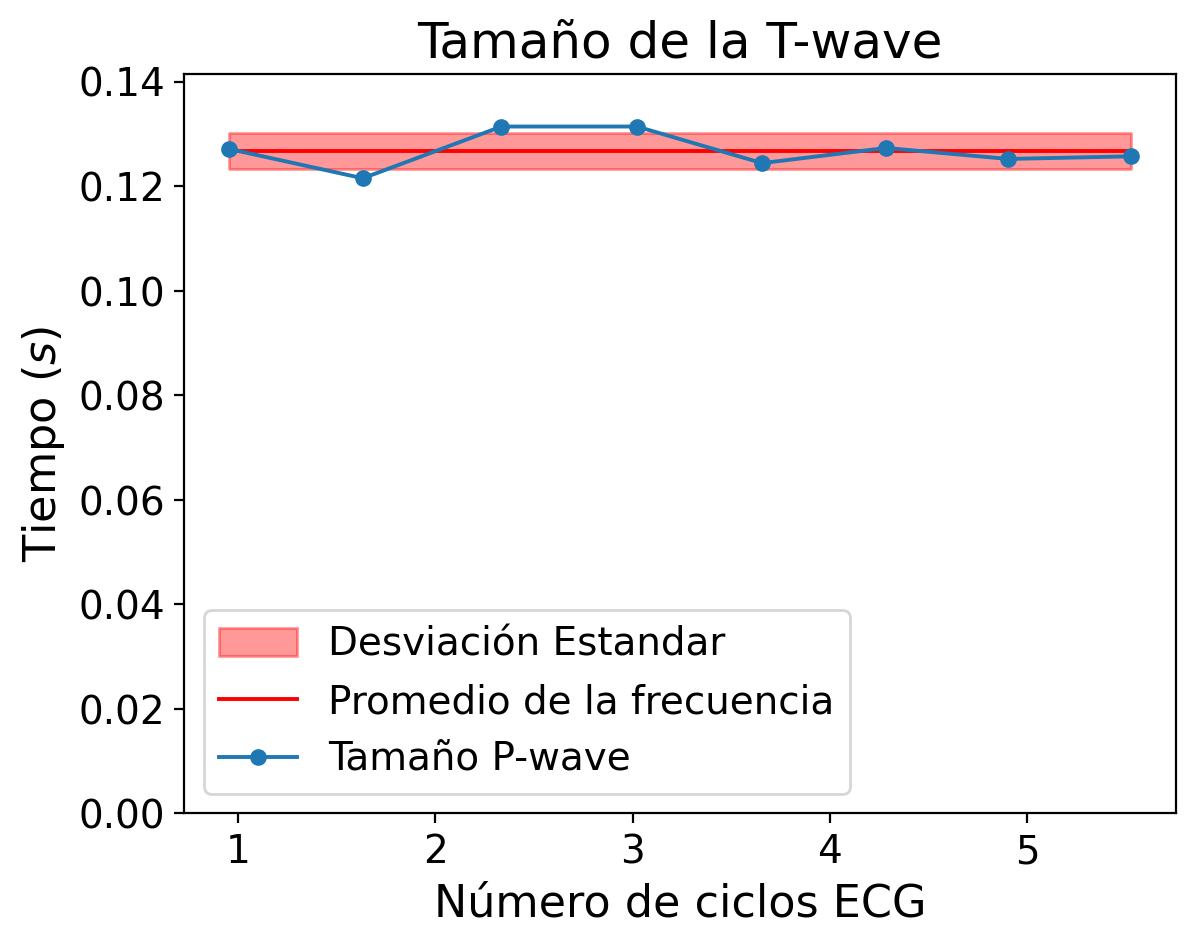

In [21]:
ECG_FR.Tamaño_Twave(mxs_indices=A,t_wave_begin=F[0], t_wave_end=F[1])